# NB - Train DenseNet121 Scratch from scratch

## Ghi chú về tính công bằng

Notebook này train mô hình **từ đầu hoàn toàn**:

- `weights=None`, không dùng ImageNet pretrained.
- Không fine-tuning vì không có backbone pretrained để fine-tune.
- Cùng dataset, split train/val/test, image size, batch size, seed, optimizer, callback và head phân loại giữa các mô hình.
- Vì dataset đã được xoay/lật/chỉnh sáng trước đó, augmentation trong notebook được giữ rất nhẹ: chỉ zoom và dịch ảnh nhẹ.
- Output được lưu trong `/kaggle/working/<model>_scratch_results/` để notebook tổng hợp đọc lại.

## 1. Import và seed

In [1]:
import os, json, random, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-05-27 06:51:57.735030: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779864717.939559      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779864718.003307      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779864718.515268      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779864718.515307      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779864718.515310      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Cấu hình chung

In [2]:
# Dataset classification 5 classes
DATASET_ROOT = '/kaggle/input/datasets/kimlonkkk/data10k-v2/split_dataset_backup_10k_v2'

TRAIN_DIR = os.path.join(DATASET_ROOT, 'train')
VAL_DIR   = os.path.join(DATASET_ROOT, 'val')
TEST_DIR  = os.path.join(DATASET_ROOT, 'test')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 60

MODEL_NAME = 'DenseNet121_Scratch'
OUTPUT_DIR = '/kaggle/working/densenet121_scratch_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('TRAIN_DIR:', TRAIN_DIR, os.path.exists(TRAIN_DIR))
print('VAL_DIR:', VAL_DIR, os.path.exists(VAL_DIR))
print('TEST_DIR:', TEST_DIR, os.path.exists(TEST_DIR))
print('OUTPUT_DIR:', OUTPUT_DIR)

TRAIN_DIR: /kaggle/input/datasets/kimlonkkk/data10k-v2/split_dataset_backup_10k_v2/train True
VAL_DIR: /kaggle/input/datasets/kimlonkkk/data10k-v2/split_dataset_backup_10k_v2/val True
TEST_DIR: /kaggle/input/datasets/kimlonkkk/data10k-v2/split_dataset_backup_10k_v2/test True
OUTPUT_DIR: /kaggle/working/densenet121_scratch_results


## 3. Load dataset

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print('Classes:', class_names)

with open(os.path.join(OUTPUT_DIR, 'class_names.json'), 'w', encoding='utf-8') as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

Found 6890 files belonging to 5 classes.


I0000 00:00:1779864752.819325      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779864752.825328      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1475 files belonging to 5 classes.
Found 1482 files belonging to 5 classes.
Classes: ['blight', 'common_rust', 'gray_spot', 'healthy', 'not_corn_leaf']


## 4. Prefetch + augmentation nhẹ

In [4]:
# Dataset đã xoay/lật/chỉnh sáng sẵn nên không dùng Flip/Rotation/Contrast nữa.
data_augmentation = keras.Sequential([
    layers.RandomZoom(0.03),
    layers.RandomTranslation(0.02, 0.02),
], name='light_augmentation')

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

## 5. Build model from scratch

In [5]:
base_model = keras.applications.DenseNet121(
    include_top=False,
    weights=None,              # QUAN TRỌNG: train từ đầu, không transfer learning
    input_shape=(224, 224, 3)
)
base_model.trainable = True

inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = base_model(x, training=True)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.40)(x)
x = layers.Dense(
    256,
    activation='relu',
    kernel_regularizer=regularizers.l2(1e-4)
)(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.40)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs, name=MODEL_NAME)

loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.05)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=['accuracy']
)

model.summary()

Model: "DenseNet121_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ light_augmentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,306,309 (27.87 MB)

 Trainable params: 7,220,101 (27.54 MB)

 Non-trainable params: 86,208 (336.75 KB)

## 6. Train

In [6]:
checkpoint_path = os.path.join(OUTPUT_DIR, 'densenet121_scratch_best.keras')

callbacks = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

history_df = pd.DataFrame(history.history)
history_df.to_csv(os.path.join(OUTPUT_DIR, 'history.csv'), index=False)
history_df.tail()

Epoch 1/60


I0000 00:00:1779864831.863603     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.6913 - loss: 1.0910
Epoch 1: val_accuracy improved from -inf to 0.19729, saving model to /kaggle/working/densenet121_scratch_results/densenet121_scratch_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 240s 751ms/step - accuracy: 0.6917 - loss: 1.0900 - val_accuracy: 0.1973 - val_loss: 2.2075 - learning_rate: 1.0000e-04
Epoch 2/60
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - accuracy: 0.8525 - loss: 0.6951
Epoch 2: val_accuracy did not improve from 0.19729
216/216 ━━━━━━━━━━━━━━━━━━━━ 156s 721ms/step - accuracy: 0.8526 - loss: 0.6949 - val_accuracy: 0.1946 - val_loss: 2.8261 - learning_rate: 1.0000e-04
Epoch 3/60
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.8829 - loss: 0.6221
Epoch 3: val_accuracy improved from 0.19729 to 0.53017, saving model to /kaggle/working/densenet121_scratch_results/densenet121_scratch_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 159s 735ms/step - accuracy: 0.8830 - loss: 0.6220 - val_accuracy: 0.5302 - val

,accuracy,loss,val_accuracy,val_loss,learning_rate
39,0.996952,0.311421,0.972203,0.367909,8.100000e-07
40,0.997678,0.309517,0.967458,0.368967,8.100000e-07
41,0.995791,0.311010,0.970169,0.367115,8.100000e-07
42,0.996081,0.311390,0.968814,0.367435,2.430000e-07
43,0.995501,0.312926,0.968814,0.367165,2.430000e-07


## 7. Learning curves

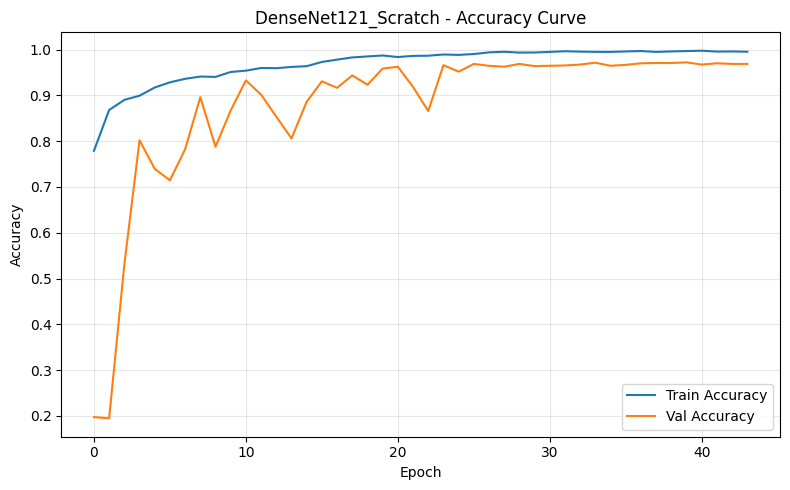

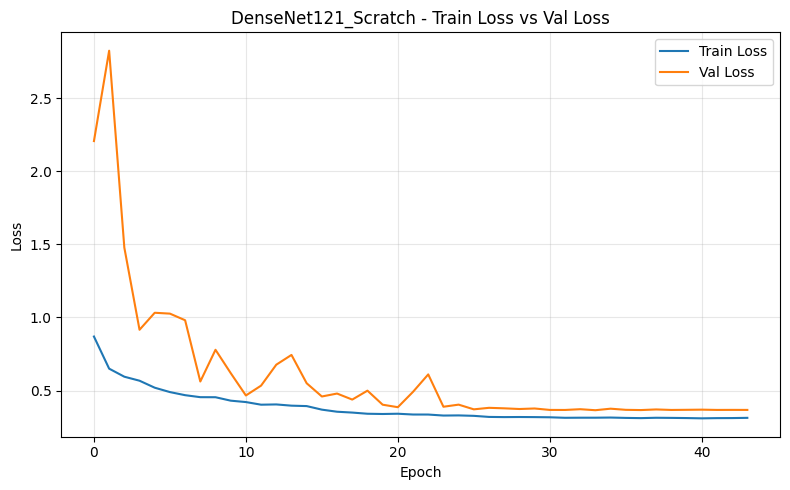

In [7]:
history_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'history.csv'))

plt.figure(figsize=(8, 5))
plt.plot(history_df['accuracy'], label='Train Accuracy')
plt.plot(history_df['val_accuracy'], label='Val Accuracy')
plt.title(f'{MODEL_NAME} - Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'accuracy_curve.png'), dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df['loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Val Loss')
plt.title(f'{MODEL_NAME} - Train Loss vs Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'loss_curve.png'), dpi=300)
plt.show()

## 8. Evaluate test set + classification report

In [8]:
best_model = keras.models.load_model(os.path.join(OUTPUT_DIR, 'densenet121_scratch_best.keras'))

test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

y_true, y_pred = [], []

for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(os.path.join(OUTPUT_DIR, 'classification_report.csv'))
display(report_df)

metrics = {
    'model_name': MODEL_NAME,
    'training_type': 'from_scratch_weights_none',
    'test_loss': float(test_loss),
    'test_accuracy': float(test_acc),
    'macro_precision': float(report_dict['macro avg']['precision']),
    'macro_recall': float(report_dict['macro avg']['recall']),
    'macro_f1': float(report_dict['macro avg']['f1-score']),
    'weighted_precision': float(report_dict['weighted avg']['precision']),
    'weighted_recall': float(report_dict['weighted avg']['recall']),
    'weighted_f1': float(report_dict['weighted avg']['f1-score']),
    'best_val_accuracy': float(history_df['val_accuracy'].max()),
    'best_val_loss': float(history_df['val_loss'].min()),
    'epochs_ran': int(len(history_df)),
    'image_size': '224x224',
    'batch_size': int(BATCH_SIZE),
    'optimizer': 'Adam(lr=1e-4)',
    'label_smoothing': 0.05,
    'augmentation': 'RandomZoom(0.03) + RandomTranslation(0.02, 0.02)'
}

with open(os.path.join(OUTPUT_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

pd.DataFrame([metrics]).to_csv(os.path.join(OUTPUT_DIR, 'summary_metrics.csv'), index=False)
metrics

47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 149ms/step - accuracy: 0.9530 - loss: 0.4067
Test loss: 0.3622288703918457
Test accuracy: 0.9723346829414368


,precision,recall,f1-score,support
blight,0.955556,0.934783,0.945055,276.000000
common_rust,0.988764,0.974170,0.981413,271.000000
gray_spot,0.956250,0.959248,0.957746,319.000000
healthy,0.992063,0.988142,0.990099,253.000000
not_corn_leaf,0.973190,1.000000,0.986413,363.000000
accuracy,0.972335,0.972335,0.972335,0.972335
macro avg,0.973165,0.971268,0.972145,1482.000000
weighted avg,0.972329,0.972335,0.972255,1482.000000


{'model_name': 'DenseNet121_Scratch',
 'training_type': 'from_scratch_weights_none',
 'test_loss': 0.3622288703918457,
 'test_accuracy': 0.9723346829414368,
 'macro_precision': 0.9731646882176672,
 'macro_recall': 0.9712684583572019,
 'macro_f1': 0.9721452233425281,
 'weighted_precision': 0.9723294868555448,
 'weighted_recall': 0.9723346828609987,
 'weighted_f1': 0.9722551289892698,
 'best_val_accuracy': 0.9722033739089966,
 'best_val_loss': 0.3651446104049682,
 'epochs_ran': 44,
 'image_size': '224x224',
 'batch_size': 32,
 'optimizer': 'Adam(lr=1e-4)',
 'label_smoothing': 0.05,
 'augmentation': 'RandomZoom(0.03) + RandomTranslation(0.02, 0.02)'}

## 9. Confusion matrix

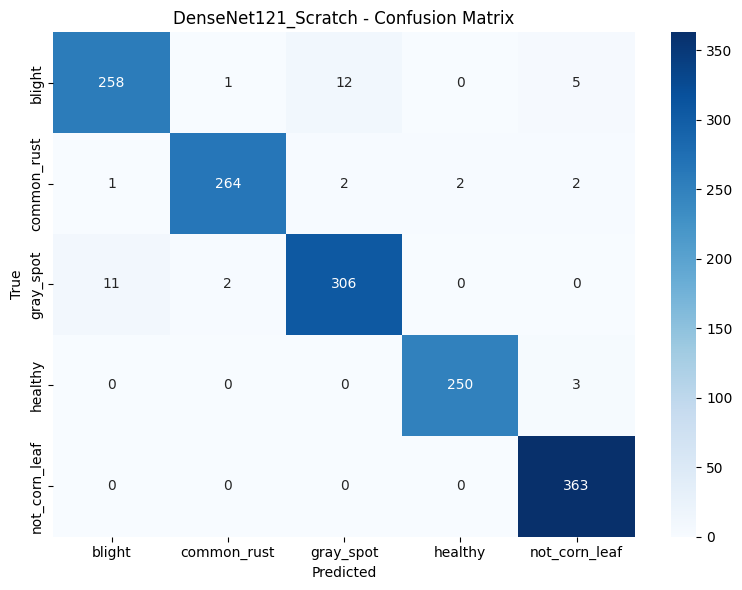

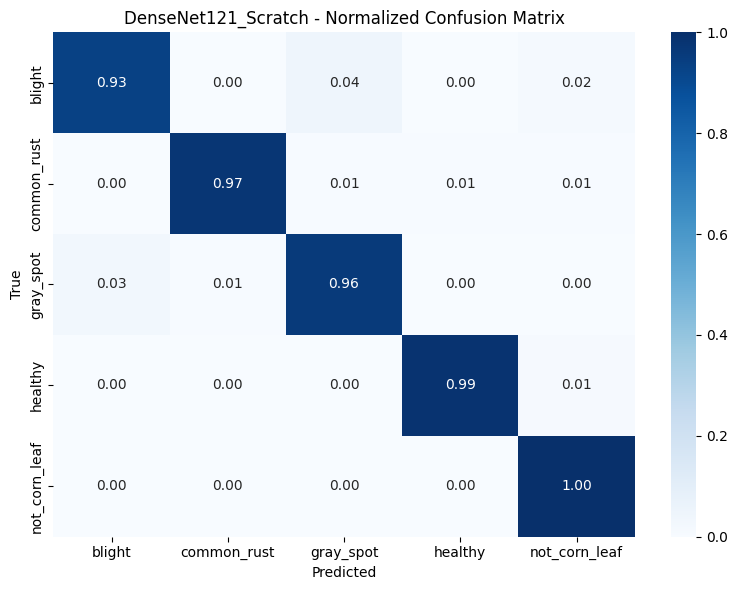

In [9]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title(f'{MODEL_NAME} - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=300)
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title(f'{MODEL_NAME} - Normalized Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_normalized.png'), dpi=300)
plt.show()

## 10. Zip output

In [10]:
zip_base = '/kaggle/working/densenet121_scratch_results'
shutil.make_archive(zip_base, 'zip', OUTPUT_DIR)
print('Output folder:', OUTPUT_DIR)
print('Zip file:', zip_base + '.zip')
print('Best model:', os.path.join(OUTPUT_DIR, 'densenet121_scratch_best.keras'))

Output folder: /kaggle/working/densenet121_scratch_results
Zip file: /kaggle/working/densenet121_scratch_results.zip
Best model: /kaggle/working/densenet121_scratch_results/densenet121_scratch_best.keras


In [11]:
# =========================
# UPLOAD ẢNH TỪ MÁY TÍNH
# =========================
from IPython.display import display
from ipywidgets import FileUpload
from PIL import Image
import io
import os

upload = FileUpload(
    accept='image/*',
    multiple=False
)

display(upload)

FileUpload(value=(), accept='image/*', description='Upload')

Load model thành công!
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


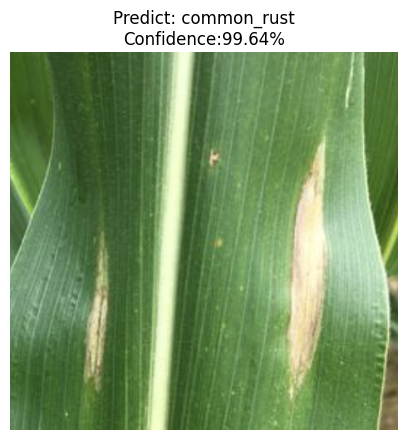

Chi tiết:
blight: 0.05%
common_rust: 99.64%
gray_spot: 0.04%
healthy: 0.25%
not_corn_leaf: 0.02%


In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io

IMG_SIZE = 224

MODEL_PATH = "/kaggle/working/densenet121_scratch_results/densenet121_scratch_best.keras"

CLASS_NAMES = [
    "blight",
    "common_rust",
    "gray_spot",
    "healthy",
    "not_corn_leaf"
]

# Load model
model = tf.keras.models.load_model(MODEL_PATH)
print("Load model thành công!")

# ===== Lấy ảnh upload =====
uploaded_file = upload.value[0]
image_bytes = uploaded_file["content"]

img = Image.open(io.BytesIO(image_bytes)).convert("RGB")

# ===== Tiền xử lý =====
img_resize = img.resize((IMG_SIZE, IMG_SIZE))

img_array = np.array(img_resize)/255.0
img_array = np.expand_dims(img_array,0)

# ===== Predict =====
pred = model.predict(img_array)

pred_class = np.argmax(pred)
confidence = np.max(pred)*100

# ===== Hiển thị =====
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Predict: {CLASS_NAMES[pred_class]}\nConfidence:{confidence:.2f}%"
)
plt.show()

print("Chi tiết:")

for name, score in zip(CLASS_NAMES,pred[0]):
    print(f"{name}: {score*100:.2f}%")